### Preprocessing + EDA
We will start by checking for missing values, and just get an overview of the dataset. We will also look at general dataset stats like genre split. 

In [5]:
import pandas as pd 

df = pd.read_csv('../data/original_dataset.csv')


# check for missing values 
print(df.isnull().sum())
# in our case there are none 

print(df.info())
print(df.describe())

# all genre value counts are reasonable in range to one another 
# but since not excat use stratify=y to preserve genre proportions in train/test split
print(df['Genre'].value_counts())

# Genre
# pop       1161
# rock      1136
# latin     1036
# hiphop     971
# edm        956
# rap        926
# r&b        731

# drop unnecessary columns 
# ex. drop time_signature since almost all songs in 4, some in 3 but won't help us predict genre
# same with other features, they will just add noise 
df = df.drop(columns=['Title', 'Album_cover_link', 'Artist', 'duration_ms', 'explicit', 'id', 
                      'release_date', 'release_date_precision', 'total_tracks', 'mode', 'time_signature'])


# now we just have the features we want 
print(df.columns)

Genre                     0
Title                     0
Album_cover_link          0
Artist                    0
duration_ms               0
explicit                  0
id                        0
popularity                0
release_date              0
release_date_precision    0
total_tracks              0
danceability              0
energy                    0
key                       0
loudness                  0
mode                      0
speechiness               0
acousticness              0
instrumentalness          0
liveness                  0
valence                   0
tempo                     0
time_signature            0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6917 entries, 0 to 6916
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Genre                   6917 non-null   object 
 1   Title                   6917 non-null   object 
 2   Album_cover_link   

### EDA

We'll plot a histogram to look at data distributions

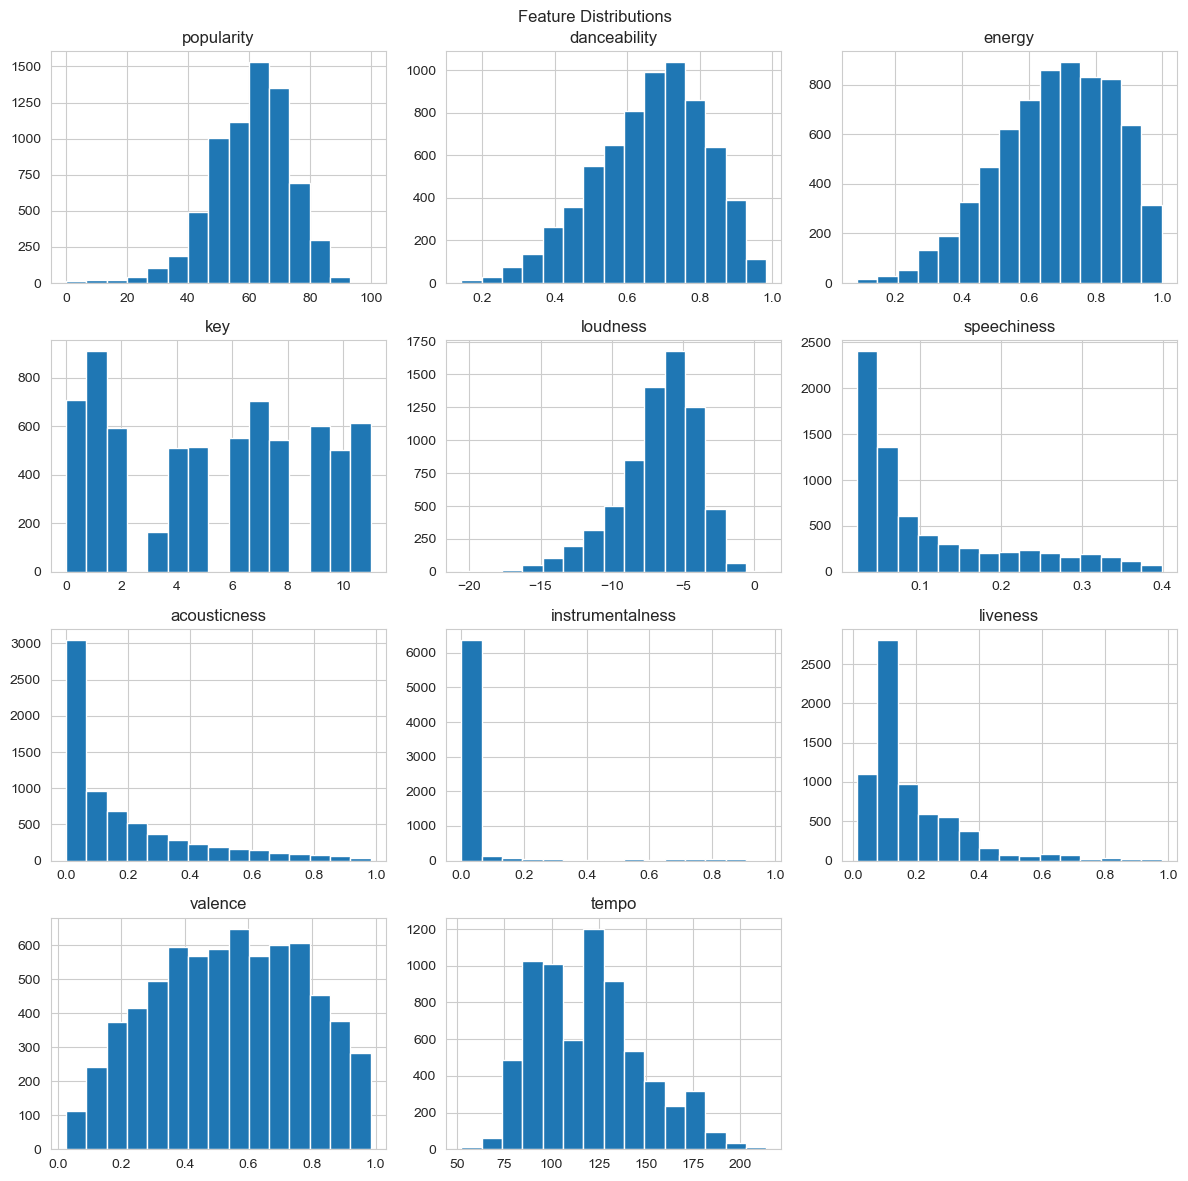

In [26]:
import matplotlib.pyplot as plt

feature_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[feature_cols].hist(figsize=(12, 12), bins=15)

plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()


As we can see from the histograms, there is a lot of right skew in many of our features, ex. speechiness, liveness, acousticness, and some left skew ex. popularity, danceability, etc. 

Now we'll generate a correlation matrix to see if any features contain redundant info 

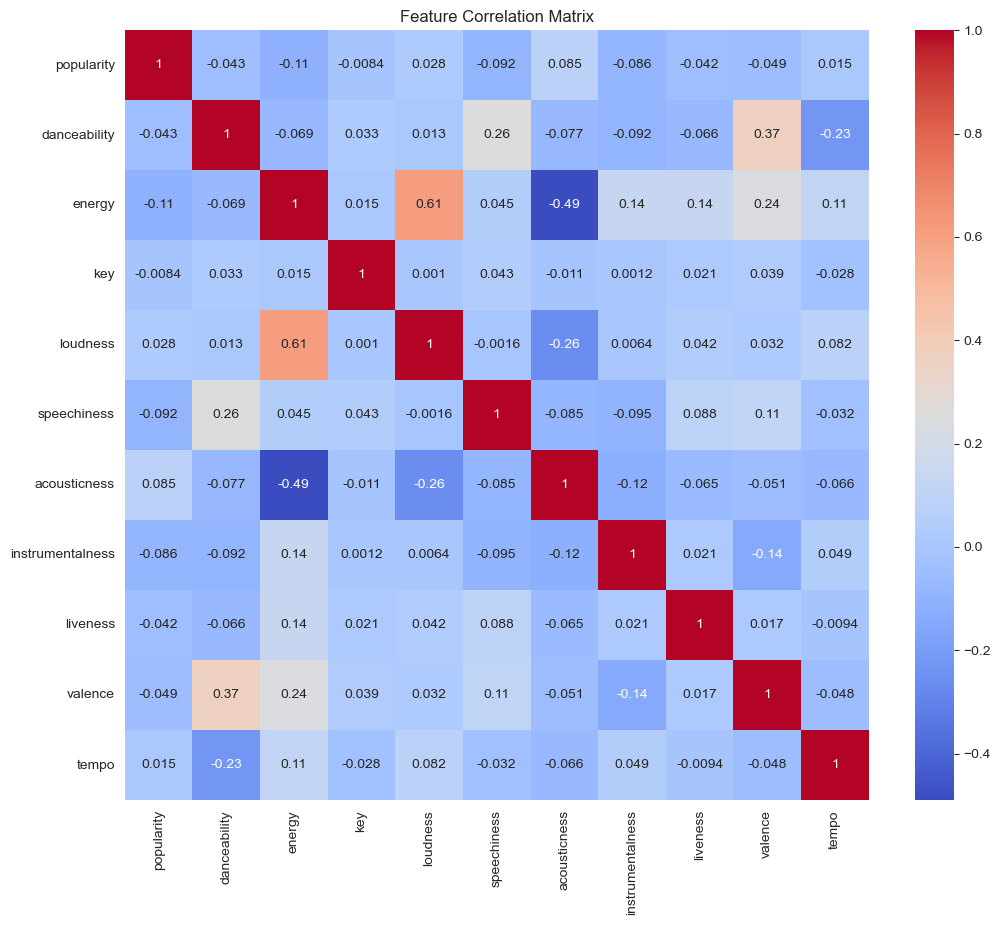

In [21]:
import seaborn as sns

plt.figure(figsize=(12, 10))

correlation_mat = df[feature_cols].corr()

sns.heatmap(correlation_mat, annot=True, cmap='coolwarm')

plt.title("Feature Correlation Matrix")
plt.show()

Judging from this correlation matrix, it doesn't appear that we have severe multicollinearity. Therefore, our features are mostly contributing unique information and it makes sense to include them all in our models. 

The strongest positive correlation is energy and loudness at r = 0.61 while the strongest negative correlation appears to be energy and acousticness at r = -0.49. This makes sense because energetic sounds tend to be louder, while acousticness songs tend to be quieter and slower-paced. 

Other features with decent correlation are danceability and valence, since happier songs tend to be more danceable, and danceability with speechiness. 

Due to there not being feature redundancy, we will elect to not perform PCA since there is no need for dimension reduction in this project. 

### Scaling, Train/Test Split, Export Dataset
We elect to use the StandardScaler method from sklearn instead of MinMaxScaler because SVM's work better with centered data, and kNN distance calculations are more balanced this way. 

We also use the standard 80/20 split for train/test. We scale after the split as well, and then export the datasets for the models to use

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Genre'])
y = df['Genre']

# we use stratify so that genre proportions are preserved in train/test split
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(
    X_train_scaled, 
    columns=X.columns
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X.columns
)

X_train_scaled_df.to_csv('../data/X_train_scaled.csv', index=False)

X_test_scaled_df.to_csv('../data/X_test_scaled.csv', index=False)

Y_train.to_csv('../data/Y_train.csv', index=False)

Y_test.to_csv('../data/Y_test.csv', index=False)


